In [1]:
import importlib
import pandas as pd
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d

d:\anaconda\envs\preprocessData\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [105]:
# RELOAD  
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record_BY.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
comb = {}
neuropil_factor = 0.1
tri_perc = 1
# ani_range = []
ani_range =[14]

for ani in ani_range:
    # Run preprocessing for each animal/session
    ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='suite2p')
    comb[ani] = {
        'n_gratings': pp.n_gratings,
        'unpred_trials': pp.unpred_trials,
        'pred_trials': pp.pred_trials,
        'trial_start_indices': pp.trial_start_indices,
        'grating_indices': pp.grating_indices,
        'dff_Zscore': pp.dff_Zscore,
        'n_planes': pp.n_planes,
        'n_trial': pp.n_trials,
        'aligned_data': pp.aligned_data,
        'reward_indices': pp.reward_indices,
        'activity': pp.activity,
        'TC': pp.TC,
        'position': pp.position,
        'position_tunnel': pp.position_tunnel,
        'speed': pp.speed,
        'trial_type': pp.trial_types,
        'pupil': pp.pupil,
        'lick': pp.lick
    }

data = {}
importlib.reload(iv)
for ani in ani_range:
    data[ani] ={}
    data[ani]['aligned_data'] = comb[ani]['aligned_data']
    data[ani]['activity'] = comb[ani]['activity']
    data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
    data[ani]['pred_trials'] = comb[ani]['pred_trials']
    data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
    data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
    data[ani]['type'] = table.iloc[ani][3]
    data[ani]['grating_indices']= comb[ani]['grating_indices']
    data[ani]['reward_indices']= comb[ani]['reward_indices']
    data[ani]['n_gratings'] = comb[ani]['n_gratings']
    data[ani]['n_trial'] = comb[ani]['n_trial']
    if table.iloc[ani][1] == 1:
        data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
        data[ani]['position'] = comb[ani]['position']
        data[ani]['speed'] = comb[ani]['speed']
        data[ani]['lick'] = comb[ani]['lick']
        data[ani]['pupil'] = comb[ani]['pupil']
    else:
        data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
        try:
            data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
            data[ani] = iv.process_pupil(data[ani])
        except KeyError:
            data[ani]['pupil'] = None

        data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
        data[ani] = iv.process_speed(data[ani])

    save_pickle(data[ani], "all_data", base_path=table.iloc[ani][2])

EmptyDataError: No columns to parse from file

In [103]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record_BY.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
neuropil_factor = 0.1
tri_perc = 1
for ani in [14]:
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

FileNotFoundError: [Errno 2] No such file or directory: 'Y:\\public\\projects\\SaEl_20220201_VIP\\2pdata\\LC\\dreadds\\LC_Dreadds_6\\D_CNO\\behavior_data\\all_data.pkl'

In [5]:
data.keys()

dict_keys([0, 1, 2, 3, 4, 5, 12])

In [6]:
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record_BY.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
table[:21]

,ctls,Unnamed: 1,behavior_data,Unnamed: 3,Unnamed: 4,suite2p,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,suite2p.1,manual
0,LC_Dreadds3,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,C,CNO,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
1,LC_Dreadds3,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,H,Saline,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
2,LC_Dreadds3,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,D,Saline,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
3,LC_Dreadds3,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,E,CNO,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
4,LC_Dreadds4,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,C,Saline,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
5,LC_Dreadds4,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,H,CNO,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
6,LC_Dreadds4,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,D,Saline,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
7,LC_Dreadds4,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,E,CNO,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
8,LC_Dreadds5,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,C,Saline,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
9,LC_Dreadds5,2.0,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,H,CNO,Y:\public\projects\SaEl_20220201_VIP\2pdata\LC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0


In [ ]:
importlib.reload(af)
importlib.reload(iv)
colors = sns.color_palette("mako", 13)
poststim_frames = slice(23,33) 
prestim_frames = slice(12,19)
max_tr, thres = 6, 0.5
blo1trials, blo2trials, sig_cells = {}, {}, {}
ani_range = [0]

for ani in ani_range:
    unpred_gratings = iv.get_unpred_grats(data[ani])
    blo1, blo2 = iv.init_trial_blocks(unpred_gratings, max_tr=max_tr)
    btri = iv.sparse_pred_trials(data[ani], unpred_gratings, max_tr, method='simple')
    data[ani]['pred_trials'] = np.setdiff1d(np.arange(data[ani]['activity']['gr_1'].shape[1]),np.concatenate(list(unpred_gratings.values())))
    if len(btri) > 0:
        blo1['gr_2'] = btri
        blo2['gr_2'] = btri
    if "X0" in blo1:
        blo1['gr_1'] = blo1["X0"]
        blo2['gr_1'] = blo2["X0"]
    blo1trials[ani], blo2trials[ani] = blo1, blo2
    mapping = {'gr_1': 'gr_1', 'gr_2': 'gr_2','X0': 'gr_2'}
    sig_cells[ani] = iv.get_sig_cells(data[ani], blo1, blo2, mapping, thres, prestim_frames, poststim_frames,method='thresh')
    

In [83]:
sorted(np.array(sig_cells[0]['gr_1']))

[36,
 43,
 97,
 182,
 259,
 266,
 301,
 305,
 339,
 348,
 394,
 416,
 455,
 580,
 715,
 716,
 830,
 853,
 901,
 913,
 936,
 985,
 1001,
 1047,
 1072,
 1082,
 1089,
 1122,
 1161,
 1194,
 1199,
 1312,
 1335,
 1403,
 1427,
 1511,
 1545,
 1556,
 1684,
 1713,
 1810]

In [101]:
data[0]['activity']['gr_2'][sig_cells[0]['X0']][:,:10].shape

(91, 10, 60)

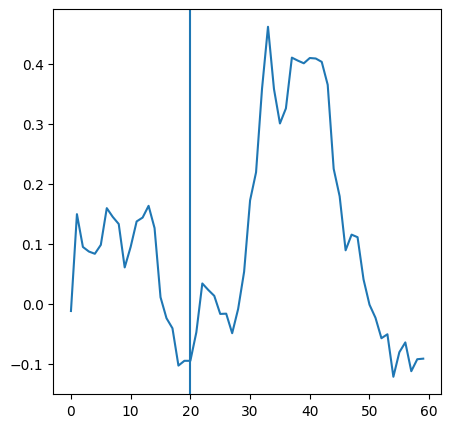

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(5,5))
plt.plot(np.mean(data[0]['activity']['gr_2'][sig_cells[0]['gr_2']][:,data[0]['unpred_trials']['gr_2'][:5]],axis=1).mean(0))
plt.axvline(x=20)

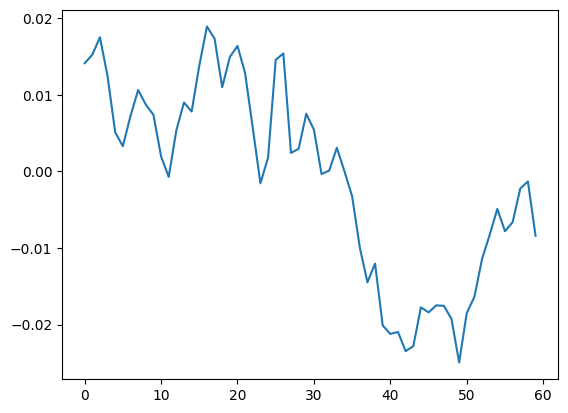

In [51]:
plt.plot(data[0]['activity']['gr_1'].mean(1).mean(0))

In [7]:
data_map = {'C_CNO':[0,12,16], 'C_Saline':[4,8], 'H_CNO':[5,9], 'H_Saline':[1,13,17],'D_CNO':[10,14],'D_Saline':[2,6,19],'E_CNO':[3,7,18],'E_Saline':[11,15], 'BY1':[16,17,18,19],'BY3':[0,1,2,3],'BY4':[4,5,6,7],'BY5':[8,9,10,11],'BY6':[12,13,14,15]}

# 0 --- CCNO
# 1 --- HSaline
# 4 --- CSaline
# 5 --- HCNO
# 8 --- CSaline
# 12--- CCNO
# 13--- HSaline
# 16--- HSaline

In [74]:
data.keys()

dict_keys([0, 1, 2, 3, 4, 5, 8, 12, 13, 16, 17, 18, 19, 10, 11])

{'C': (array([4, 8]), array([ 0, 12, 16])), 'H': (array([ 1, 13, 17]), array([5])), 'D': (array([ 2, 19]), array([10])), 'E': (array([11]), array([ 3, 18]))}
[4 8] & [ 0 12 16]


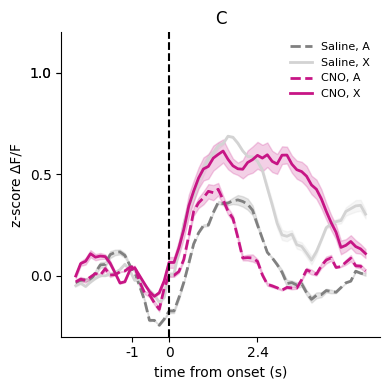

[ 1 13 17] & [5]


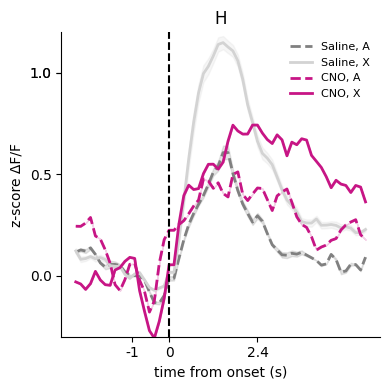

[ 2 19] & [10]


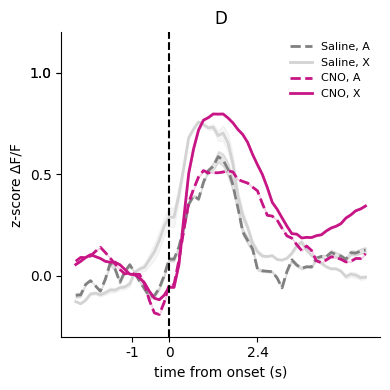

[11] & [ 3 18]


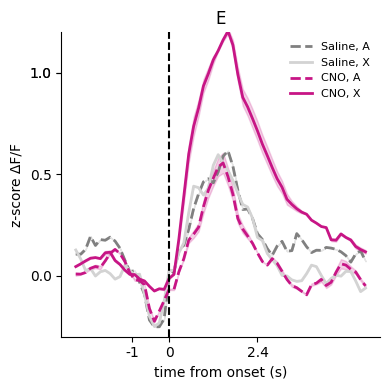

In [155]:
# Plot PSTH

groups = {'C': (np.intersect1d(data_map['C_Saline'], list(data.keys())),
                np.intersect1d(data_map['C_CNO'], list(data.keys()))),
    'H': (np.intersect1d(data_map['H_Saline'], list(data.keys())),
          np.intersect1d(data_map['H_CNO'], list(data.keys()))),
    'D': (np.intersect1d(data_map['D_Saline'], list(data.keys())),
          np.intersect1d(data_map['D_CNO'], list(data.keys()))),
    'E': (np.intersect1d(data_map['E_Saline'], list(data.keys())),
          np.intersect1d(data_map['E_CNO'], list(data.keys()))),}

print(groups)    

# groups = {'C': ([8],[0,12,16]),'D&E':([3,10,18],[2,16,19])}

# groups = {'C&H': ([1,4,8,13,17],[0,5,12,16]),'D&E':([2,11,19],[3,10,18])}

# groups = {'C&H': ([0,12,16],[8]),'D&E':([3,10,18],[2,16,19])}


for i in groups:
    ctl = groups[i][0]
    tst = groups[i][1]
    print(ctl,'&',tst)
    fig, axes = plt.subplots(1, 1, figsize=(4,4))
    sal = []
    sal_unpred = []
    for _,ani in enumerate(ctl):
        trials = data[ani]['unpred_trials']['gr_2'][:6]
        arr = data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:]
        baseline = arr[:, :, 10:15].mean(axis=-1,keepdims=True)      # 0.5s before stim
        arr = arr-baseline
        sal.append(arr.mean(axis=(0,1)))
        arr2 = data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,trials,:]
        baseline = arr2[:, :, 10:15].mean(axis=-1,keepdims=True)
        arr2 = arr2-baseline
        sal_unpred.append(arr2.mean(axis=(0,1)))
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='Saline, A',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='lightgrey',label='Saline, X')

    cno = []
    cno_unpred = []
    for _,ani in enumerate(tst):
        trials = data[ani]['unpred_trials']['gr_2'][:6]
        arr = data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:]
        baseline = arr[:, :, 10:15].mean(axis=-1,keepdims=True)
        arr = arr-baseline
        cno.append(arr.mean(axis=(0,1)))
        arr2 = data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,trials,:]
        baseline = arr2[:, :, 10:15].mean(axis=-1,keepdims=True)
        arr2 = arr2-baseline
        cno_unpred.append(arr2.mean(axis=(0,1)))
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO, A',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO, X')

    axes.set_ylabel('z-score ΔF/F')
    axes.set_yticks([0,0.5,1,1])
    axes.set_xticks([11.5, 19, 37])
    axes.set_xticklabels(['-1', '0', '2.4'])
    axes.set_ylim([-0.3,1.2])
    axes.set_title(i,fontsize=12)
    axes.axvline(19, linestyle='--', color='k')
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.set_xlabel('time from onset (s)')
    axes.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

[1] & [0]


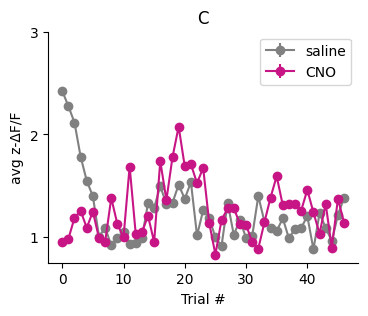

In [ ]:
groups = {'C': (np.intersect1d(data_map['C_Saline'], list(data.keys())),
                np.intersect1d(data_map['C_CNO'], list(data.keys()))),
    'H': (np.intersect1d(data_map['H_Saline'], list(data.keys())),
          np.intersect1d(data_map['H_CNO'], list(data.keys()))),
    'D': (np.intersect1d(data_map['D_Saline'], list(data.keys())),
          np.intersect1d(data_map['D_CNO'], list(data.keys()))),
    'E': (np.intersect1d(data_map['E_Saline'], list(data.keys())),
          np.intersect1d(data_map['E_CNO'], list(data.keys()))),}


# groups = {'C':([8],[0,12,16]),'H':([1],[5]),'D':([2],[10])}

groups = {'C':([1],[0])}


for i in groups:
    ctl = groups[i][0]
    tst = groups[i][1]
    print(ctl,'&',tst)
    fig, axes = plt.subplots(1, 1, figsize=(4,3))
    min_trials = min([len(data[ani]['unpred_trials']['gr_2']) for ani in np.union1d(ctl,tst)])
    x_vals = list(range(min_trials))
    axes.set_ylabel('avg z-ΔF/F')
    poststim_frames = slice(23,30)
    sal = []
    for _,ani in enumerate(ctl):
        arr = data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:min_trials],:]
        baseline = arr[:, :, 15:19].mean(axis=-1,keepdims=True)
        arr = arr-baseline
        sal.append(np.mean(np.max(arr[:, : , poststim_frames], axis=2), axis=0))
    axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='grey', label='saline')

    cno = []
    for _,ani in enumerate(tst):
        arr2 = data[ani]['activity']['gr_2'][sig_cells[ani]['X0']][:,data[ani]['unpred_trials']['gr_2'][:min_trials],:]
        baseline = arr2[:, :, 15:19].mean(axis=-1,keepdims=True)
        arr2 = arr2-baseline        
        cno.append(np.mean(np.max(arr2[:, :, poststim_frames], axis=2), axis=0))
    axes.errorbar(x_vals, np.mean(cno, axis=0),np.std(cno, axis=0) / np.sqrt(len(cno)),fmt='o-', color='mediumvioletred', label='CNO')


    axes.set_yticks([1,2,3])
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.set_title(i,fontsize=12)
    axes.set_xlabel('Trial #')
    axes.legend()

Text(45.722222222222214, 0.5, '# neurons')

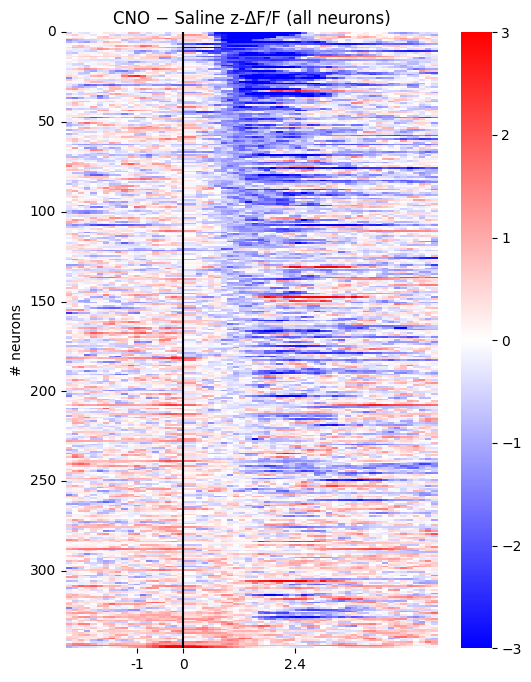

In [166]:
# heatmap of CNO - saline for the same responsive cells in saline trials

grat = 'gr_2'
min_trials = 6
sort_frames = slice(23, 30)
vmin, vmax = -3, 3
all_neurons = []
ani_list = [0,4]

for ani in ani_list: 
    activity_cno = data[ani]['activity'][grat][sig_cells[ani+1]['X0']]
    activity_saline = data[ani + 1]['activity'][grat][sig_cells[ani+1]['X0']]

    trials_cno = data[ani]['unpred_trials'][grat][:min_trials]
    trials_saline = data[ani + 1]['unpred_trials'][grat][:min_trials]

    plot_data = np.mean(activity_cno[:, trials_cno, :], axis=1) - np.mean(activity_saline[:, trials_saline, :], axis=1) # response difference in cno and saline trials
    all_neurons.append(plot_data)
    
all_neurons = np.vstack(all_neurons)
sort_idx = np.argsort(np.mean(all_neurons[:, sort_frames], axis=1))  # sort by mean poststim response
all_neurons_sorted = all_neurons[sort_idx]

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
sns.heatmap(all_neurons_sorted, ax=ax, cmap='bwr', cbar=True,vmin=vmin,vmax=vmax)

ax.set_xticks([11.5, 19, 37])
ax.set_xticklabels(['-1', '0', '2.4'])
ax.axvline(19, linestyle='-', color='k')
ax.set_title(f'CNO − Saline z-ΔF/F (all neurons)')

y_ticks = np.arange(0, all_neurons_sorted.shape[0], 50)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks)
ax.set_ylabel('# neurons')


Text(0, 0.5, 'CNO')

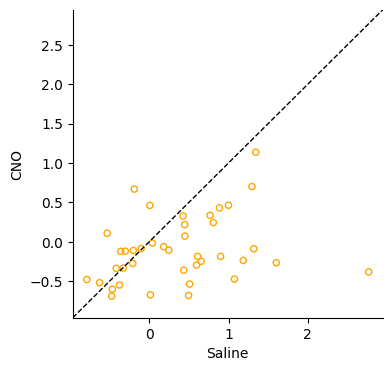

In [169]:
# Scatter plot CNO v.s. Saline for the same responsive cells in saline trials

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
min_trials = 6
grat = 'gr_2'
stim = 'X0'
for ani in ani_list:
    sess_cno = ani
    sess_saline = ani + 1
    rois_both = np.intersect1d(sig_cells[sess_cno][stim],sig_cells[sess_saline][stim]) # rois that have sig response on both CNO and saline sessions
    rois = sig_cells[sess_saline][stim]
    # for roi in rois:
    #     cno_val = np.mean(np.mean(data[sess_cno]['activity'][grat][roi][data[sess_cno]['unpred_trials']['gr_2'][:min_trials], poststim_frames],axis=1))
    #     saline_val = np.mean(np.mean(data[sess_saline]['activity'][grat][roi][data[sess_saline]['unpred_trials']['gr_2'][:min_trials], poststim_frames],axis=1))
    #     ax.scatter(saline_val,cno_val, facecolor='none', edgecolor='black',s=20)
    for roi in rois_both:
        cno_val = np.mean(np.mean(data[sess_cno]['activity'][grat][roi][data[sess_cno]['unpred_trials']['gr_2'][:min_trials], poststim_frames],axis=1))
        saline_val = np.mean(np.mean(data[sess_saline]['activity'][grat][roi][data[sess_saline]['unpred_trials']['gr_2'][:min_trials], poststim_frames],axis=1))
        ax.scatter(saline_val,cno_val,facecolor='none', edgecolor='orange',s=20)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, 'k--', lw=1) # set the x and y coordinate limits
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Saline')
ax.set_ylabel('CNO')


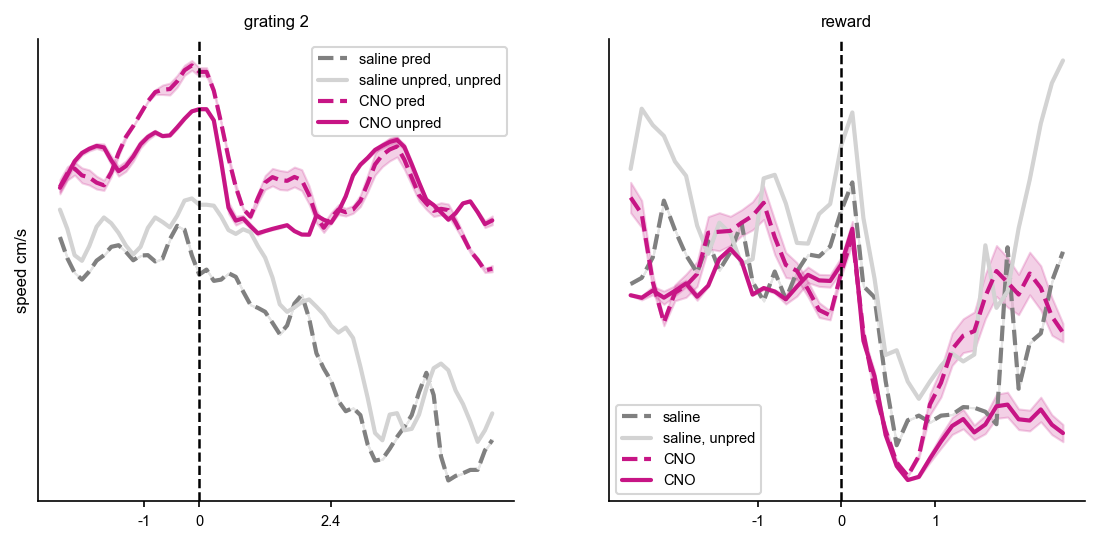

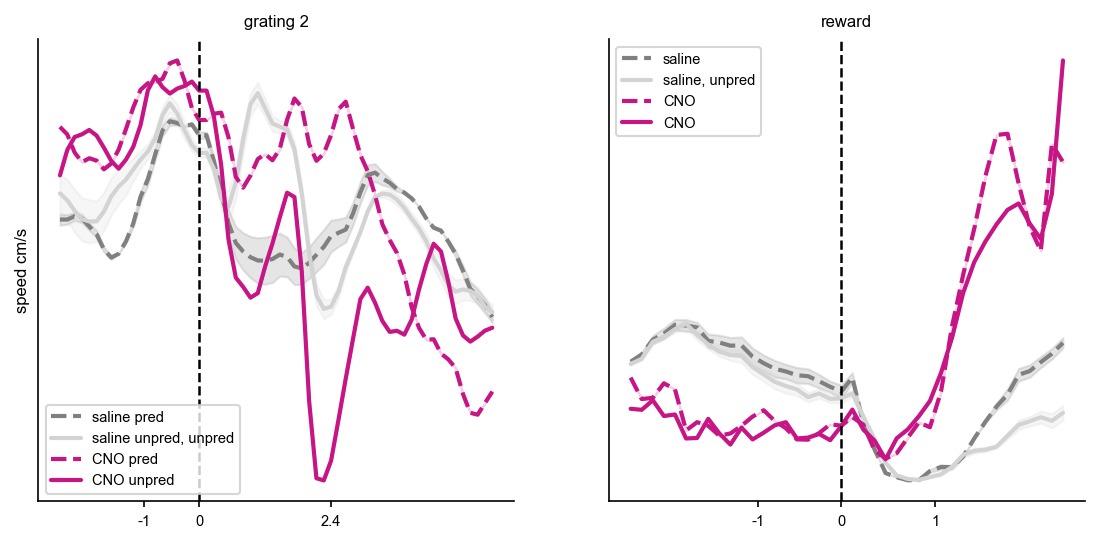

In [291]:
groups = {'C': (np.intersect1d(data_map['C_Saline'], list(data.keys())),
                np.intersect1d(data_map['C_CNO'], list(data.keys()))),
    'H': (np.intersect1d(data_map['H_Saline'], list(data.keys())),
          np.intersect1d(data_map['H_CNO'], list(data.keys()))),}

for i in groups:
    ctl = groups[i][0]
    tst = groups[i][1]
    fig, ax = plt.subplots(1, 2, figsize=(9,4))
    axes = ax[0]
    grat = 'gr_2'
    trials = blo1trials[ani][grat]
    sal = []
    sal_unpred = []
    for _,ani in enumerate(ctl):
        sal.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,:],axis=0))
        sal_unpred.append(np.nanmean(data[ani]['speed_cm_s'][grat][data[ani]['unpred_trials'][grat][:6],:],axis=0))

    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline pred',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='lightgrey',label='saline unpred, unpred')

    cno = []
    cno_unpred = []
    for _,ani in enumerate(tst):
        cno.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,:],axis=0))
        cno_unpred.append(np.nanmean(data[ani]['speed_cm_s'][grat][data[ani]['unpred_trials'][grat][:6],:],axis=0))

    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO pred',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO unpred')

    axes.set_ylabel('speed cm/s')
    axes.set_yticks([])
    axes.set_xticks([11.5, 19, 37])
    axes.set_xticklabels(['-1', '0', '2.4'])
    axes.axvline(19, linestyle='--', color='k')
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.set_title('grating 2')
    axes = ax[1]
    grat = 'gr_2'
    trials = blo1trials[ani][grat]
    sal = []
    sal_unpred = []
    for _,ani in enumerate(ctl):
        sal.append(np.nanmean(data[ani]['speed_cm_s']['rew'][trials,:],axis=0))
        sal_unpred.append(np.nanmean(data[ani]['speed_cm_s']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

    viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal),color='grey',label='saline',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(sal_unpred),color='lightgrey',label='saline, unpred')

    cno = []
    cno_unpred = []
    for _,ani in enumerate(tst):
        cno.append(np.nanmean(data[ani]['speed_cm_s']['rew'][trials,:],axis=0))
        cno_unpred.append(np.nanmean(data[ani]['speed_cm_s']['rew'][data[ani]['unpred_trials'][grat][:8],:],axis=0))

    viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno),color='mediumvioletred',label='CNO',style='dash')
    viz.plot_shaded_error(axes,x_vals=np.arange(40),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO')

    axes.axvline(19, linestyle='--', color='k')
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.set_yticks([])
    axes.set_xticks([11.5, 19, 27.5])
    axes.set_xticklabels(['-1', '0', '1'])
    axes.set_title('reward')